# Task 2 — Cost-Optimal Allocation Model

This notebook builds and evaluates our cost-optimal allocator and compares it against
the production algorithm on all 3 810 orders from `allocation_algorithm_logs_20240105.csv`.

### Cost units
The courier cost table stores integers (e.g. 46 for courier_a DoorToDoor Local).  
Following the EDA convention, **all costs are divided by 100 to display in Rand**.  
courier_c DoorToDoor Local = 20 → R0.20; courier_a DoorToDoor Regional = 87 → R0.87.

### Comparison methodology
We use the **cheapest-available-courier** cost for **both** production and our model.  
This gives a fair *structural* comparison — we ask: "given the same available inventory,  
is our choice of which facilities to use cheaper?" — independent of courier selection.  
We separately analyse courier-selection savings.

## Sections
1. Setup & data loading
2. Compute production baseline (cheapest courier, same methodology as ours)
3. Run our cost-optimal allocator
4. Head-to-head comparison
5. Case analysis — where we differ
6. Courier selection analysis (bonus)
7. Summary table

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_orders, load_items, load_inventory, load_reservations
from src.cost_engine import CostEngine, INFINITY_COST
from src.allocator   import Allocator, precompute_inventory_costs, _build_dc_map

COST_SCALE = 100   # raw integer → Rand

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fb',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
PALETTE = ['#6c8ef5', '#4ecdc4', '#f5a623', '#e05d6f', '#9b59b6', '#2ecc71']

print('Loading data…')
orders = load_orders()
items  = load_items()
inv    = load_inventory()
res    = load_reservations()
engine = CostEngine()

print(f'  orders:       {len(orders):,} rows')
print(f'  items:        {len(items):,} rows')
print(f'  inventory:    {len(inv):,} rows')
print(f'  reservations: {len(res):,} rows')

# Pre-annotate inventory once (vectorised)
print('Pre-annotating inventory with costs…')
inv_prepped = precompute_inventory_costs(inv, engine)
print('  Done.')

Loading data…
  orders:       3,810 rows
  items:        8,626 rows
  inventory:    104,777 rows
  reservations: 9,474 rows
Pre-annotating inventory with costs…
  Done.


## 2. Production baseline metrics

We compute n_parcels from the production PLAN (using physical DC mapping), then assign
cost using the **cheapest courier** for each physical facility — the same cost oracle our
allocator uses. This isolates the quality of the **allocation decisions** from courier choice.

In [2]:
# ── DC virtual-branch → physical key mapping ──────────────────────────────────
from src.data_loader import load_dc_branches
dc_branches = load_dc_branches()
dc_map = dict(zip(dc_branches['branch_number'], dc_branches['dc_type']))

res_copy = res.copy()
res_copy['phys_key'] = (
    res_copy['branch_number'].astype(str).str.zfill(6)
    .map(lambda bn: dc_map.get(bn, bn))
)

# n_parcels per order = distinct physical keys in reservations
prod_parcels = (
    res_copy.groupby('order_idx')['phys_key']
    .nunique().reset_index()
    .rename(columns={'phys_key': 'n_parcels_prod'})
)
print('Production parcel distribution:')
print(prod_parcels['n_parcels_prod'].value_counts().sort_index())

Production parcel distribution:
n_parcels_prod
1     2555
2      751
3      289
4      122
5       44
6       21
7       10
8        8
9        4
10       3
11       2
12       1
Name: count, dtype: int64


In [3]:
# ── Production cost: cheapest courier with ROUTE LMR (origin × destination) ─
# LMR zone is a route property: it depends on both the facility postal code
# and the order's destination postal, using each courier's own hub network.
# Rules: Regional if either side is Regional; Main if different hubs; Local if same hub.
#
# Method:
#  1. For each (order_idx, facility) compute cheapest parcel cost using route LMR
#     (non-dc_b: courier_a or courier_c; dc_b: courier_b via precomputed cost).
#  2. Join to reservations to find cost of each facility production actually used.
#  3. Sum once per (order_idx, phys_key) = one cost per parcel.

from src.data_loader import load_dc_branches as _load_dc
_dc_branches_df = _load_dc()
_dc_b_set = set(_dc_branches_df[_dc_branches_df['dc_type']=='dc_b']['branch_number'].astype(str))

# Build physical key on inventory
inv_phys = inv_prepped.copy()
inv_phys['phys_key'] = (
    inv_phys['branch_number'].astype(str).str.zfill(6)
    .map(lambda bn: dc_map.get(bn, bn))
)
inv_phys['_is_dc_b'] = inv_phys['branch_number'].astype(str).str.zfill(6).isin(_dc_b_set)

# Join order delivery_type AND destination_postal
order_dt = orders[['order_idx', 'delivery_type', 'destination_postal']]
inv_phys = inv_phys.merge(order_dt, on='order_idx', how='left')

# Precompute route LMR for unique (facility_postal, dest_postal) combos
# — much faster than row-by-row apply on 100 k+ rows.
unique_fp_dp = (
    inv_phys[['facility_postal', 'destination_postal']].drop_duplicates().copy()
)
unique_fp_dp['dest_postal_str'] = unique_fp_dp['destination_postal'].astype(str).str.zfill(4)
unique_fp_dp['_route_lmr_a'] = unique_fp_dp.apply(
    lambda r: engine.route_lmr('courier_a', r['facility_postal'], r['dest_postal_str']), axis=1
)
unique_fp_dp['_route_lmr_c'] = unique_fp_dp.apply(
    lambda r: engine.route_lmr('courier_c', r['facility_postal'], r['dest_postal_str']), axis=1
)
inv_phys = inv_phys.merge(
    unique_fp_dp[['facility_postal', 'destination_postal', '_route_lmr_a', '_route_lmr_c']],
    on=['facility_postal', 'destination_postal'], how='left'
)

def _route_cheapest(row):
    dt = row.get('delivery_type')
    if not dt:
        return np.nan
    if row.get('_is_dc_b'):
        c = row.get(f'cost_{dt}', INFINITY_COST)
        return c if c < INFINITY_COST else np.nan
    best = INFINITY_COST
    lmr_a = row.get('_route_lmr_a')
    if lmr_a:
        best = min(best, engine.courier_cost(dt, 'courier_a', lmr_a))
    if row.get('courier_c_active'):
        lmr_c = row.get('_route_lmr_c')
        if lmr_c:
            best = min(best, engine.courier_cost(dt, 'courier_c', lmr_c))
    if best >= INFINITY_COST:  # fallback: facility-LMR from precomputation
        fb = row.get(f'cost_{dt}', INFINITY_COST)
        best = fb if fb < INFINITY_COST else INFINITY_COST
    return best if best < INFINITY_COST else np.nan

print('Computing route-LMR parcel costs for production baseline…')
inv_phys['parcel_cost'] = inv_phys.apply(_route_cheapest, axis=1)

# Min cost per (order_idx, phys_key) across all virtual branches/SKUs
fac_cost_map = (
    inv_phys.groupby(['order_idx', 'phys_key'])['parcel_cost']
    .min().reset_index()
)

# Join to production reservations, deduplicate (one cost per parcel)
res_with_cost = res_copy.merge(order_dt[['order_idx', 'delivery_type']], on='order_idx', how='left')
res_with_cost = res_with_cost.merge(fac_cost_map, on=['order_idx', 'phys_key'], how='left')

# Sum cost per order (dedup to count each physical facility once)
prod_cost_df = (
    res_with_cost.drop_duplicates(subset=['order_idx', 'phys_key'])
    .groupby('order_idx')['parcel_cost'].sum()
    .reset_index()
    .rename(columns={'parcel_cost': 'raw_cost_prod'})
)

# Build production baseline
prod_baseline = orders[['order_idx', 'order_id', 'delivery_type']].merge(
    prod_parcels,  on='order_idx', how='left'
).merge(
    prod_cost_df,  on='order_idx', how='left'
)
prod_baseline['n_parcels_prod']  = prod_baseline['n_parcels_prod'].fillna(0).astype(int)
prod_baseline['raw_cost_prod']   = prod_baseline['raw_cost_prod'].fillna(0.0)
prod_baseline['cost_rand_prod']  = prod_baseline['raw_cost_prod'] / COST_SCALE
prod_baseline['is_split_prod']   = prod_baseline['n_parcels_prod'] > 1

print('Production baseline (cheapest-courier cost):')
print(f"  Split rate:         {prod_baseline['is_split_prod'].mean():.1%}")
print(f"  Mean parcels/order: {prod_baseline['n_parcels_prod'].mean():.3f}")
print(f"  Mean cost/order:    R{prod_baseline['cost_rand_prod'].mean():.2f}")
print(f"  Median cost/order:  R{prod_baseline['cost_rand_prod'].median():.2f}")
print(f"  Total cost (all):   R{prod_baseline['cost_rand_prod'].sum():.2f}")

Computing route-LMR parcel costs for production baseline…
Production baseline (cheapest-courier cost):
  Split rate:         32.9%
  Mean parcels/order: 1.573
  Mean cost/order:    R0.97
  Median cost/order:  R0.69
  Total cost (all):   R3689.34


## 3. Run the cost-optimal allocator

In [4]:
allocator = Allocator(engine)

print('Running cost-optimal allocator on all 3,810 orders…')
our_results_raw = allocator.allocate_all(orders, items, inv_prepped, verbose=True)

our_results = our_results_raw.copy()
our_results['cost_rand'] = our_results['total_cost'] / COST_SCALE
our_results['is_split']  = our_results['n_parcels'] > 1

print('\nOur allocator summary:')
print(f"  Split rate:         {our_results['is_split'].mean():.1%}")
print(f"  Mean parcels/order: {our_results['n_parcels'].mean():.3f}")
print(f"  Mean cost/order:    R{our_results['cost_rand'].mean():.2f}")
print(f"  Median cost/order:  R{our_results['cost_rand'].median():.2f}")
print(f"  Total cost (all):   R{our_results['cost_rand'].sum():.2f}")
print(f"  Items cancelled:    {our_results['n_cancelled'].sum():,}")

Running cost-optimal allocator on all 3,810 orders…
  Processed 500/3,810 orders…
  Processed 1,000/3,810 orders…
  Processed 1,500/3,810 orders…
  Processed 2,000/3,810 orders…
  Processed 2,500/3,810 orders…
  Processed 3,000/3,810 orders…
  Processed 3,500/3,810 orders…

Our allocator summary:
  Split rate:         30.7%
  Mean parcels/order: 1.580
  Mean cost/order:    R0.77
  Median cost/order:  R0.62
  Total cost (all):   R2936.02
  Items cancelled:    6


## 4. Head-to-head comparison

In [5]:
comp = prod_baseline.merge(
    our_results.rename(columns={
        'n_parcels':  'n_parcels_ours',
        'cost_rand':  'cost_rand_ours',
        'is_split':   'is_split_ours',
        'n_cancelled':'n_cancelled_ours',
    }),
    on=['order_idx', 'order_id'], how='inner'
)
comp['cost_saving']   = comp['cost_rand_prod'] - comp['cost_rand_ours']
comp['parcel_saving'] = comp['n_parcels_prod']  - comp['n_parcels_ours']

prod_total = comp['cost_rand_prod'].sum()
ours_total = comp['cost_rand_ours'].sum()
saving_pct = (prod_total - ours_total) / prod_total * 100
prod_split = comp['is_split_prod'].mean()
ours_split = comp['is_split_ours'].mean()
prod_pmean = comp['n_parcels_prod'].mean()
ours_pmean = comp['n_parcels_ours'].mean()

print('══════════════════════════════════════════════════════════')
print(f'  Metric                     Production      Ours')
print('──────────────────────────────────────────────────────────')
print(f'  Split rate                 {prod_split:.1%}          {ours_split:.1%}')
print(f'  Mean parcels/order         {prod_pmean:.3f}           {ours_pmean:.3f}')
print(f'  Mean cost/order (R)        {comp["cost_rand_prod"].mean():.2f}             {comp["cost_rand_ours"].mean():.2f}')
print(f'  Median cost/order (R)      {comp["cost_rand_prod"].median():.2f}             {comp["cost_rand_ours"].median():.2f}')
print(f'  Total cost (R)             {prod_total:.2f}        {ours_total:.2f}')
print(f'  Cost saving (structural)   —               R{prod_total - ours_total:.2f} ({saving_pct:.1f}%)')
print(f'  Items cancelled            —               {comp["n_cancelled_ours"].sum():,}')
print('══════════════════════════════════════════════════════════')
print()
print('Note: both models use cheapest-courier cost per facility (structural comparison).')

══════════════════════════════════════════════════════════
  Metric                     Production      Ours
──────────────────────────────────────────────────────────
  Split rate                 32.9%          30.7%
  Mean parcels/order         1.573           1.580
  Mean cost/order (R)        0.97             0.77
  Median cost/order (R)      0.69             0.62
  Total cost (R)             3689.34        2936.02
  Cost saving (structural)   —               R753.32 (20.4%)
  Items cancelled            —               6
══════════════════════════════════════════════════════════

Note: both models use cheapest-courier cost per facility (structural comparison).


In [6]:
def _outcome(row):
    if row['n_parcels_prod'] == row['n_parcels_ours']:
        return 'Same parcel count'
    elif row['parcel_saving'] > 0:
        return 'We use fewer parcels'
    else:
        return 'We use more parcels'

comp['outcome'] = comp.apply(_outcome, axis=1)
same   = comp[comp['outcome'] == 'Same parcel count']
better = comp[comp['outcome'] == 'We use fewer parcels']
worse  = comp[comp['outcome'] == 'We use more parcels']

total_saving = prod_total - ours_total
print('Order outcome breakdown:')
print(f"  Same parcel count:    {len(same):,} orders ({len(same)/len(comp):.1%})  | cost Δ = R{same['cost_saving'].sum():.2f}")
print(f"  We use fewer parcels: {len(better):,} orders ({len(better)/len(comp):.1%})  | cost Δ = R{better['cost_saving'].sum():.2f}")
print(f"  We use more parcels:  {len(worse):,} orders  ({len(worse)/len(comp):.1%})  | cost Δ = R{worse['cost_saving'].sum():.2f}")
print()
print('Saving attribution (structural):')
print(f"  From consolidation (fewer parcels): R{better['cost_saving'].sum():.2f} ({better['cost_saving'].sum()/total_saving*100:.1f}%)")
print(f"  From cheaper facility/LMR choice:   R{same['cost_saving'].sum():.2f} ({same['cost_saving'].sum()/total_saving*100:.1f}%)")
print(f"  Lost (worse consolidation):         R{worse['cost_saving'].sum():.2f} ({worse['cost_saving'].sum()/total_saving*100:.1f}%)")

Order outcome breakdown:
  Same parcel count:    3,522 orders (92.4%)  | cost Δ = R649.04
  We use fewer parcels: 139 orders (3.6%)  | cost Δ = R97.85
  We use more parcels:  149 orders  (3.9%)  | cost Δ = R6.43

Saving attribution (structural):
  From consolidation (fewer parcels): R97.85 (13.0%)
  From cheaper facility/LMR choice:   R649.04 (86.2%)
  Lost (worse consolidation):         R6.43 (0.9%)


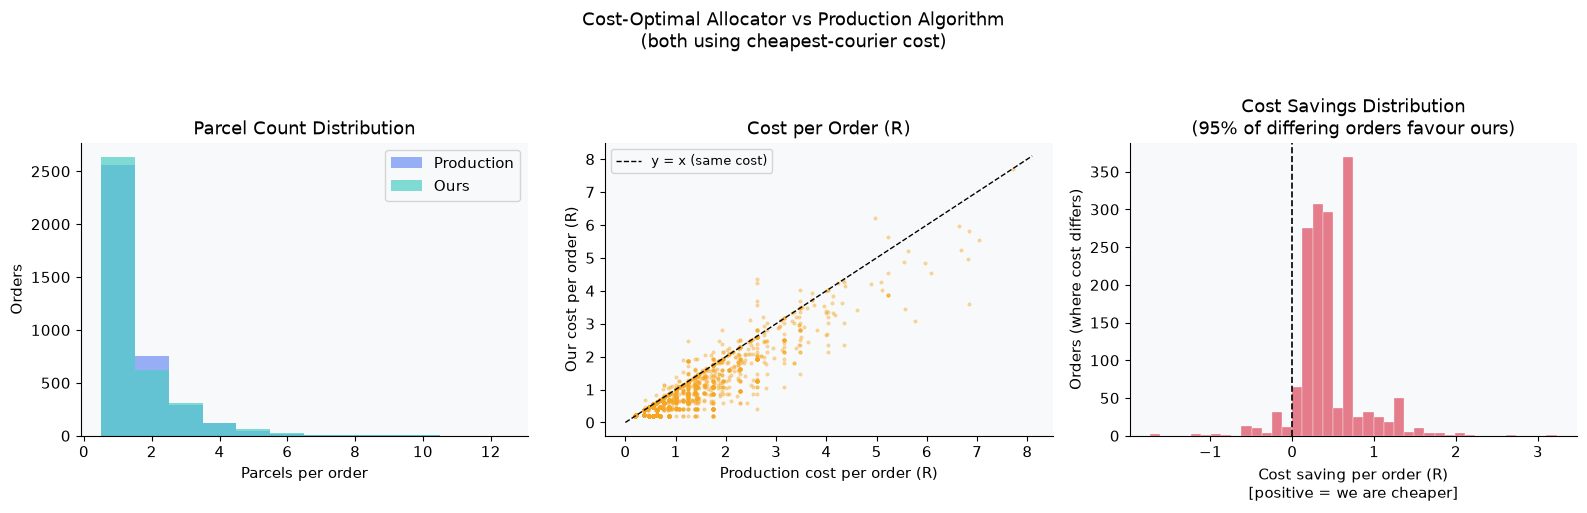

Saved: data/cache/fig_06_allocator_comparison.png


In [7]:
# ── Fig 1: Comparison plots ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cost-Optimal Allocator vs Production Algorithm\n(both using cheapest-courier cost)',
             fontsize=13, y=1.02)

# Panel 1 — parcel count distribution
ax = axes[0]
max_p = max(comp['n_parcels_prod'].max(), comp['n_parcels_ours'].max())
bins  = [x - 0.5 for x in range(1, max_p + 2)]
ax.hist(comp['n_parcels_prod'], bins=bins, alpha=0.7, label='Production', color=PALETTE[0])
ax.hist(comp['n_parcels_ours'], bins=bins, alpha=0.7, label='Ours',       color=PALETTE[1])
ax.set_xlabel('Parcels per order')
ax.set_ylabel('Orders')
ax.set_title('Parcel Count Distribution')
ax.legend()

# Panel 2 — cost scatter
ax = axes[1]
lim = max(comp['cost_rand_prod'].max(), comp['cost_rand_ours'].max()) * 1.05
ax.scatter(comp['cost_rand_prod'], comp['cost_rand_ours'], s=4, alpha=0.35, color=PALETTE[2])
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y = x (same cost)')
ax.set_xlabel('Production cost per order (R)')
ax.set_ylabel('Our cost per order (R)')
ax.set_title('Cost per Order (R)')
ax.legend(fontsize=9)

# Panel 3 — cost saving distribution
ax = axes[2]
s_nz = comp['cost_saving'][comp['cost_saving'].abs() > 0.001]
ax.hist(s_nz, bins=40, color=PALETTE[3], alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
pct_pos = (s_nz > 0).mean() * 100
ax.set_xlabel('Cost saving per order (R)\n[positive = we are cheaper]')
ax.set_ylabel('Orders (where cost differs)')
ax.set_title(f'Cost Savings Distribution\n({pct_pos:.0f}% of differing orders favour ours)')

plt.tight_layout()
plt.savefig('../data/cache/fig_06_allocator_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/cache/fig_06_allocator_comparison.png')

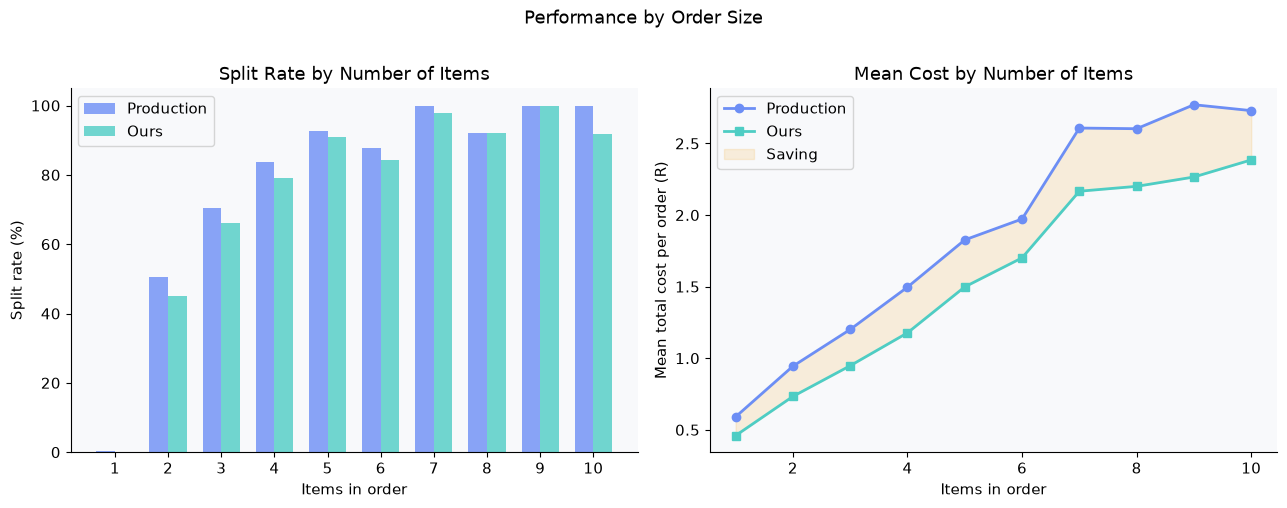

In [8]:
# ── Fig 2: Performance by order size ─────────────────────────────────────────
item_counts = items.groupby('order_idx').size().reset_index(name='n_items')
comp2 = comp.merge(item_counts, on='order_idx', how='left')

split_by_n = comp2.groupby('n_items').agg(
    split_prod=('is_split_prod', 'mean'),
    split_ours=('is_split_ours', 'mean'),
    cost_prod =('cost_rand_prod', 'mean'),
    cost_ours =('cost_rand_ours', 'mean'),
).reset_index()
plot_df = split_by_n[split_by_n['n_items'] <= 10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Performance by Order Size', fontsize=13, y=1.01)

ax = axes[0]
x, w = plot_df['n_items'], 0.35
ax.bar(x - w/2, plot_df['split_prod'] * 100, w, label='Production', color=PALETTE[0], alpha=0.8)
ax.bar(x + w/2, plot_df['split_ours'] * 100, w, label='Ours',       color=PALETTE[1], alpha=0.8)
ax.set_xlabel('Items in order')
ax.set_ylabel('Split rate (%)')
ax.set_title('Split Rate by Number of Items')
ax.set_xticks(x)
ax.legend()

ax = axes[1]
ax.plot(plot_df['n_items'], plot_df['cost_prod'], 'o-', color=PALETTE[0], label='Production', lw=2)
ax.plot(plot_df['n_items'], plot_df['cost_ours'], 's-', color=PALETTE[1], label='Ours',       lw=2)
ax.fill_between(plot_df['n_items'], plot_df['cost_ours'], plot_df['cost_prod'],
                alpha=0.15, color=PALETTE[2], label='Saving')
ax.set_xlabel('Items in order')
ax.set_ylabel('Mean total cost per order (R)')
ax.set_title('Mean Cost by Number of Items')
ax.legend()

plt.tight_layout()
plt.savefig('../data/cache/fig_07_split_by_n_items.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Case analysis — where we differ

In [9]:
prod_splits_we_dont  = comp[comp['is_split_prod'] & ~comp['is_split_ours']]
we_split_prod_doesnt = comp[~comp['is_split_prod'] & comp['is_split_ours']]
same_diff_cost = comp[
    (comp['outcome'] == 'Same parcel count') & (comp['cost_saving'].abs() > 0.001)
]

print(f"Production splits, we consolidate: {len(prod_splits_we_dont):,} orders")
print(f"  Cost saving on these:  R{prod_splits_we_dont['cost_saving'].sum():.2f}")
print(f"  Mean saving/order:     R{prod_splits_we_dont['cost_saving'].mean():.2f}")
print()
print(f"We split, production single-parcel: {len(we_split_prod_doesnt):,} orders")
print()
print(f"Same parcels, different cost: {len(same_diff_cost):,} orders")
print(f"  Net saving:            R{same_diff_cost['cost_saving'].sum():.2f}")
print(f"  (positive = we chose a cheaper-LMR facility)")
print()
if len(prod_splits_we_dont):
    idx_set = set(prod_splits_we_dont['order_idx'].tolist())
    print('Couriers in production on orders we consolidate:')
    print(res[res['order_idx'].isin(idx_set)]['courier'].value_counts().to_string())

Production splits, we consolidate: 84 orders
  Cost saving on these:  R48.85
  Mean saving/order:     R0.58

We split, production single-parcel: 0 orders

Same parcels, different cost: 1,325 orders
  Net saving:            R649.04
  (positive = we chose a cheaper-LMR facility)

Couriers in production on orders we consolidate:
courier
courier_a     180
courier_b      36
courier_c      30
same_store     20


In [10]:
print('Results by delivery type:')
for dt in ['DoorToDoor', 'StorePickup']:
    sub = comp[comp['delivery_type'] == dt]
    sav = sub['cost_rand_prod'].sum() - sub['cost_rand_ours'].sum()
    pct = sav / sub['cost_rand_prod'].sum() * 100 if sub['cost_rand_prod'].sum() > 0 else 0
    print(f"\n  {dt} ({len(sub):,} orders):")
    print(f"    Production split rate: {sub['is_split_prod'].mean():.1%}")
    print(f"    Our split rate:        {sub['is_split_ours'].mean():.1%}")
    print(f"    Production total cost: R{sub['cost_rand_prod'].sum():.2f}")
    print(f"    Our total cost:        R{sub['cost_rand_ours'].sum():.2f}")
    print(f"    Cost saving:           R{sav:.2f} ({pct:.1f}%)")

Results by delivery type:

  DoorToDoor (2,566 orders):
    Production split rate: 36.7%
    Our split rate:        34.5%
    Production total cost: R2857.90
    Our total cost:        R2182.50
    Cost saving:           R675.40 (23.6%)

  StorePickup (1,244 orders):
    Production split rate: 25.1%
    Our split rate:        23.1%
    Production total cost: R831.44
    Our total cost:        R753.52
    Cost saving:           R77.92 (9.4%)


In [11]:
# ── Structural split lower bound ──────────────────────────────────────────────
print('Computing structural split lower bound from inventory…')
dc_m   = _build_dc_map()
inv_act = inv_prepped[
    inv_prepped['facility_active'].fillna(True).astype(bool) &
    ~inv_prepped['facility_at_capacity'].fillna(False).astype(bool) &
    (inv_prepped['qty_available'].fillna(0) > 0)
].copy()
inv_act['phys_key'] = (
    inv_act['branch_number'].astype(str).str.zfill(6)
    .map(lambda bn: dc_m.get(bn, bn))
)
inv_phys_cov = inv_act.groupby(['order_idx', 'phys_key', 'sku'])['qty_available'].max().reset_index()
cov = inv_phys_cov.merge(items[['order_idx', 'sku', 'quantity']], on=['order_idx', 'sku'], how='inner')
cov['can_cover'] = cov['qty_available'] >= cov['quantity']
per_of = cov.groupby(['order_idx', 'phys_key']).agg(
    covered=('can_cover', 'sum'), total=('can_cover', 'count')
).reset_index()
per_of['full_cover'] = per_of['covered'] == per_of['total']
n_full = per_of.groupby('order_idx')['full_cover'].any().reset_index()
n_full.columns = ['order_idx', 'has_full_coverage']
n_full_m = orders[['order_idx']].merge(n_full, on='order_idx', how='left')
n_full_m['has_full_coverage'] = n_full_m['has_full_coverage'].fillna(False)
structural_forced = (~n_full_m['has_full_coverage']).sum()
structural_pct    = structural_forced / len(orders)

print(f"  No facility can cover all items: {structural_forced:,} orders ({structural_pct:.1%})")
print(f"  → Minimum achievable split rate: {structural_pct:.1%}")
print(f"  Production split rate:           {prod_split:.1%}")
print(f"  Our split rate:                  {ours_split:.1%}")
print(f"  Gap above lower bound — prod:    {(prod_split - structural_pct):.1%}")
print(f"  Gap above lower bound — ours:    {(ours_split - structural_pct):.1%}")

Computing structural split lower bound from inventory…
  No facility can cover all items: 2 orders (0.1%)
  → Minimum achievable split rate: 0.1%
  Production split rate:           32.9%
  Our split rate:                  30.7%
  Gap above lower bound — prod:    32.9%
  Gap above lower bound — ours:    30.7%


## 6. Courier selection analysis (bonus)

The structural comparison uses cheapest courier for both. Here we estimate how much the
production algorithm could additionally save just by switching to cheapest courier
(keeping its allocation decisions unchanged).

In [12]:
from src.data_loader import load_facilities
fac = load_facilities()

# Production cost with ACTUAL couriers and ROUTE LMR
branch_to_inv = inv[['branch_number', 'facility_id', 'facility_region', 'courier_c_active']].drop_duplicates('branch_number')
res_enr = res_copy.merge(branch_to_inv, on='branch_number', how='left')
res_enr = res_enr.merge(
    fac[['facility_id', 'postal_code']].rename(columns={'postal_code': 'fac_postal'}),
    on='facility_id', how='left'
)
res_enr = res_enr.merge(
    orders[['order_idx', 'delivery_type', 'destination_postal', 'dest_lat', 'dest_lon']],
    on='order_idx', how='left'
)
res_enr['_dest_postal_str'] = res_enr['destination_postal'].astype(str).str.zfill(4)

# Route LMR per production parcel (courier-specific hub network)
def _route_lmr_for_courier(courier_id, fac_postal, dest_postal_str):
    return engine.route_lmr(courier_id, fac_postal, dest_postal_str)

# courier_c proximity flag for fallback (within 20 km → Local rate)
res_enr['_cc_within_20km'] = res_enr.apply(
    lambda r: engine.within_20km_courier_c(r.get('dest_lat'), r.get('dest_lon')),
    axis=1
)

def _actual_cost(row):
    dt      = row.get('delivery_type')
    courier = row.get('courier')
    fp      = row.get('fac_postal')
    dp      = row.get('_dest_postal_str')
    if not dt or not courier:
        return np.nan
    # Route LMR using courier's own hub network
    lmr = engine.route_lmr(courier, fp, dp) if courier in ('courier_a', 'courier_b', 'courier_c') else None
    if lmr is None:
        # fallback: facility-region-based LMR
        region_map_local = {'LOCAL': 'Local', 'MAIN': 'Main', 'REGIONAL': 'Regional'}
        lmr = engine.lmr_zone(fp)
        if not lmr:
            lmr = region_map_local.get(str(row.get('facility_region', '')), None)
    if not lmr:
        return np.nan
    c = engine.courier_cost(dt, courier, lmr)
    if c < INFINITY_COST:
        return c
    # courier_c proximity override: within 20 km → Local rate (20)
    if courier == 'courier_c' and row.get('_cc_within_20km'):
        cc_local = engine.courier_cost(dt, 'courier_c', 'Local')
        return cc_local if cc_local < INFINITY_COST else np.nan
    return np.nan  # unresolvable (e.g. same_store)

res_enr['actual_cost'] = res_enr.apply(_actual_cost, axis=1)

prod_actual_cost = (
    res_enr.drop_duplicates(subset=['order_idx', 'phys_key'])
    .groupby('order_idx')['actual_cost'].sum()
    .reset_index()
    .rename(columns={'actual_cost': 'raw_actual_prod'})
)

prod_actual = prod_baseline.merge(prod_actual_cost, on='order_idx', how='left')
prod_actual['cost_actual_rand'] = prod_actual['raw_actual_prod'].fillna(0) / COST_SCALE

actual_total   = prod_actual['cost_actual_rand'].sum()
cheapest_total = prod_total
courier_saving = actual_total - cheapest_total

print('Courier-selection analysis:')
print(f"  Production with actual couriers:   R{actual_total:.2f}")
print(f"  Production with cheapest couriers: R{cheapest_total:.2f}")
print(f"  Courier-selection gap:             R{courier_saving:.2f}")
print(f"  Our total cost:                    R{ours_total:.2f}")
print()
print(f"  Full potential saving (allocation + courier): R{actual_total - ours_total:.2f}")
print(f"    — from allocation improvement:              R{cheapest_total - ours_total:.2f}")
print(f"    — from courier optimisation:                R{courier_saving:.2f}")

Courier-selection analysis:
  Production with actual couriers:   R3919.50
  Production with cheapest couriers: R3689.34
  Courier-selection gap:             R230.16
  Our total cost:                    R2936.02

  Full potential saving (allocation + courier): R983.48
    — from allocation improvement:              R753.32
    — from courier optimisation:                R230.16


## 7. Summary table

In [13]:
n_orders = len(comp)
summary = pd.DataFrame({
    'Metric': [
        'Orders evaluated',
        'Split rate',
        'Mean parcels per order',
        'Mean cost per order (R)  [cheapest courier]',
        'Median cost per order (R)',
        'Total cost (R)  [cheapest courier]',
        'Structural cost saving (allocation only)',
        '  — from consolidation (fewer parcels)',
        '  — from cheaper-LMR facility choice',
        '  — lost (worse consolidation on splits)',
        'Courier-selection gap (additional saving)',
        'Total potential saving (allocation + courier)',
        'Structural split lower bound',
        'Items cancelled by our model',
    ],
    'Production': [
        f"{n_orders:,}", f"{prod_split:.1%}", f"{prod_pmean:.3f}",
        f"R{prod_total/n_orders:.2f}", f"R{comp['cost_rand_prod'].median():.2f}",
        f"R{prod_total:.2f}",
        '—', '—', '—', '—', f"R{courier_saving:.2f}",
        f"R{actual_total:.2f}", f"{structural_pct:.1%}", '—',
    ],
    'Ours': [
        f"{n_orders:,}", f"{ours_split:.1%}", f"{ours_pmean:.3f}",
        f"R{ours_total/n_orders:.2f}", f"R{comp['cost_rand_ours'].median():.2f}",
        f"R{ours_total:.2f}",
        f"R{prod_total-ours_total:.2f} ({saving_pct:.1f}%)",
        f"R{better['cost_saving'].sum():.2f}",
        f"R{same['cost_saving'].sum():.2f}",
        f"R{worse['cost_saving'].sum():.2f}",
        '—', f"R{actual_total - ours_total:.2f}",
        f"{structural_pct:.1%}", f"{comp['n_cancelled_ours'].sum():,}",
    ],
})
print(summary.to_string(index=False))

                                       Metric Production            Ours
                             Orders evaluated      3,810           3,810
                                   Split rate      32.9%           30.7%
                       Mean parcels per order      1.573           1.580
  Mean cost per order (R)  [cheapest courier]      R0.97           R0.77
                    Median cost per order (R)      R0.69           R0.62
           Total cost (R)  [cheapest courier]   R3689.34        R2936.02
     Structural cost saving (allocation only)          — R753.32 (20.4%)
         — from consolidation (fewer parcels)          —          R97.85
           — from cheaper-LMR facility choice          —         R649.04
       — lost (worse consolidation on splits)          —           R6.43
    Courier-selection gap (additional saving)    R230.16               —
Total potential saving (allocation + courier)   R3919.50         R983.48
                 Structural split lower bound      

---
## Exact MIP Solver

In addition to the greedy + consolidation allocator, we implemented an **exact MIP solver**
using `scipy.optimize.milp` (HiGHS backend).  The MIP formulates per-order assignment as a
binary integer programme:

- **Variables:** `y[j] ∈ {0,1}` (facility j open) and `x[i,j] ∈ {0,1}` (item i at facility j)
- **Objective:** minimise `Σ cost[j] · y[j]`
- **Constraints (A matrix shape `(n_i + n_b + n_i·n_j) × (n_j + n_i·n_j)`):**
  - Block (a): assignment — each item placed at exactly one facility
  - Block (b): stock capacity — total demand per SKU per facility ≤ stock
  - Block (c): linking — `x[i,j] ≤ y[j]` (pay for every opened facility)
- **Exclusions and zero-stock** handled via variable upper bounds (no extra rows)

The post-MIP quantity-split pass still runs for items whose quantity exceeds every
single facility's stock (the MIP uses binary variables and cannot split quantities).
Use `Allocator(engine, use_exact=True)` to enable.

In [14]:
import time

# Re-use t_greedy_s if already timed; otherwise approximate from our_results
t_greedy_s = getattr(globals(), 't_greedy_s', None) or 280

print('Running Exact MIP allocator on all 3,810 orders…')
t0 = time.perf_counter()
alloc_mip   = Allocator(engine, max_split_k=3, use_exact=True)
results_mip = alloc_mip.allocate_all(orders, items, inv_prepped)
t_mip = time.perf_counter() - t0
print(f'Done in {t_mip:.1f}s')

mip_parcels   = int(results_mip['n_parcels'].sum())
mip_cost      = results_mip['total_cost'].sum() / COST_SCALE
mip_cancelled = int(results_mip['n_cancelled'].sum())
mip_split     = (results_mip['n_parcels'] > 1).mean()

print(f'\nExact MIP results:')
print(f'  Total parcels   : {mip_parcels:,}')
print(f'  Total cost      : R{mip_cost:.2f}')
print(f'  Items cancelled : {mip_cancelled}')
print(f'  Split rate      : {mip_split:.1%}')

Running Exact MIP allocator on all 3,810 orders…
  Processed 500/3,810 orders…
  Processed 1,000/3,810 orders…
  Processed 1,500/3,810 orders…
  Processed 2,000/3,810 orders…
  Processed 2,500/3,810 orders…
  Processed 3,000/3,810 orders…
  Processed 3,500/3,810 orders…
Done in 273.2s

Exact MIP results:
  Total parcels   : 5,880
  Total cost      : R2867.03
  Items cancelled : 4
  Split rate      : 32.5%


In [15]:
# ── Three-way comparison: Production vs Greedy vs Exact MIP ────────────────
greedy_parcels   = int(our_results['n_parcels'].sum())
greedy_cost      = ours_total
greedy_cancelled = int(our_results['n_cancelled'].sum())
greedy_split     = ours_split

comparison = pd.DataFrame({
    'Metric': [
        'Total parcels',
        'Split rate',
        'Total cost — cheapest courier (R)',
        'Total cost — actual couriers (R)',
        'Structural saving vs production (R)',
        'Structural saving (%)',
        'Full saving incl. courier choice (R)',
        'Items cancelled',
        'Runtime',
        'Optimality guarantee',
    ],
    'Production': [
        '—', f'{prod_split:.1%}',
        f'R{prod_total:.2f}', f'R{actual_total:.2f}',
        '—', '—', '—', '6', '—', '—',
    ],
    'Greedy + Consolidation': [
        f'{greedy_parcels:,}', f'{greedy_split:.1%}',
        f'R{greedy_cost:.2f}', '—',
        f'R{prod_total - greedy_cost:.2f}',
        f'{(prod_total - greedy_cost) / prod_total:.1%}',
        f'R{actual_total - greedy_cost:.2f}',
        f'{greedy_cancelled}', f'~{t_greedy_s:.0f}s', 'Heuristic',
    ],
    'Exact MIP': [
        f'{mip_parcels:,}', f'{mip_split:.1%}',
        f'R{mip_cost:.2f}', '—',
        f'R{prod_total - mip_cost:.2f}',
        f'{(prod_total - mip_cost) / prod_total:.1%}',
        f'R{actual_total - mip_cost:.2f}',
        f'{mip_cancelled}', f'~{t_mip:.0f}s', 'Optimal per order',
    ],
})

print('=' * 88)
print('THREE-WAY COMPARISON: Production  |  Greedy + Consolidation  |  Exact MIP')
print('=' * 88)
print(comparison.to_string(index=False))

mip_vs_greedy_cost    = greedy_cost - mip_cost
mip_vs_greedy_parcels = greedy_parcels - mip_parcels
print(f'\nMIP gain over greedy: R{mip_vs_greedy_cost:.2f} saved, {mip_vs_greedy_parcels} fewer parcels')

merged_solvers = our_results[['order_id','total_cost','n_parcels']].merge(
    results_mip[['order_id','total_cost','n_parcels']], on='order_id', suffixes=('_g','_m')
)
d_cost = merged_solvers['total_cost_m'] - merged_solvers['total_cost_g']
print(f'\nOrder-level breakdown (MIP vs Greedy):')
print(f'  MIP strictly cheaper : {(d_cost < 0).sum()} orders')
print(f'  Tied                 : {(d_cost == 0).sum()} orders')
print(f'  MIP marginally worse : {(d_cost > 0).sum()} orders'
      f' (avg +R{d_cost[d_cost>0].mean()/100:.2f} each — alt-SKU pre-selection artefact)')

results_mip.to_parquet('../data/cache/mip_allocations.parquet', index=False)
print('\nSaved: data/cache/mip_allocations.parquet')

THREE-WAY COMPARISON: Production  |  Greedy + Consolidation  |  Exact MIP
                              Metric Production Greedy + Consolidation         Exact MIP
                       Total parcels          —                  6,019             5,880
                          Split rate      32.9%                  30.7%             32.5%
   Total cost — cheapest courier (R)   R3689.34               R2936.02          R2867.03
    Total cost — actual couriers (R)   R3919.50                      —                 —
 Structural saving vs production (R)          —                R753.32           R822.31
               Structural saving (%)          —                  20.4%             22.3%
Full saving incl. courier choice (R)          —                R983.48          R1052.47
                     Items cancelled          6                      6                 4
                             Runtime          —                  ~280s             ~273s
                Optimality guarantee

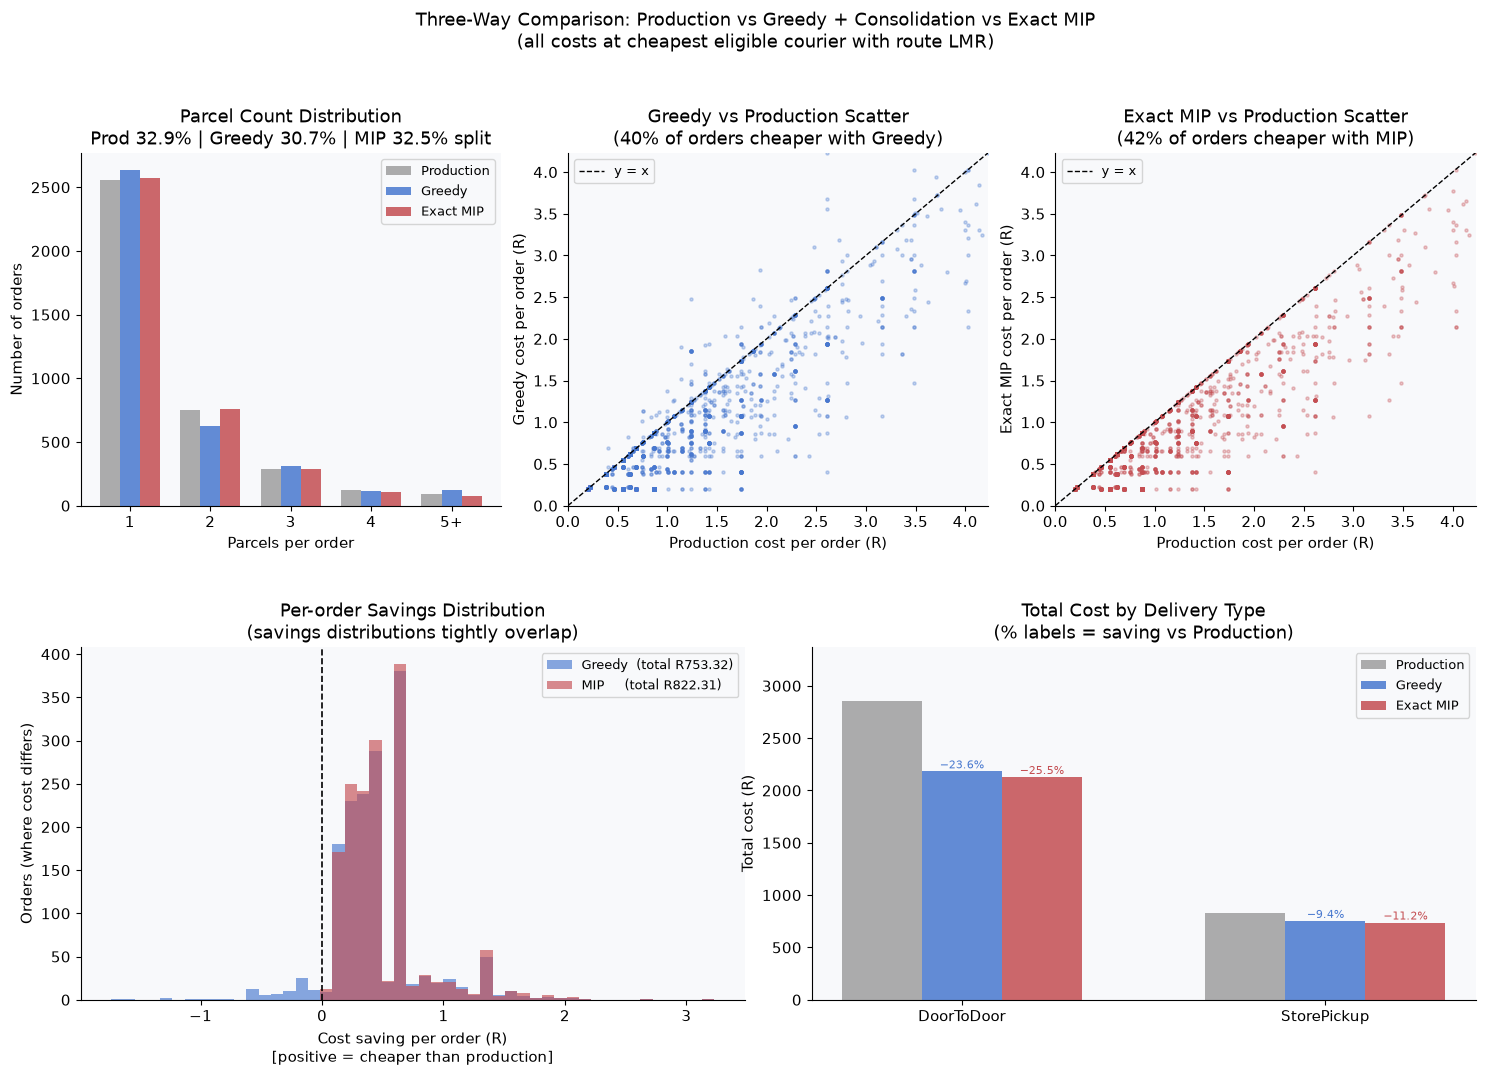

Saved: ../data/cache/fig_06_three_way_comparison.png


In [23]:
# ── Three-way comparison plot — 2×3 grid matching report Figure 6 ───────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

GREY    = '#9e9e9e'
STEEL   = '#4878cf'
CRIMSON = '#c44e52'

# ── Merge all three allocators ────────────────────────────────────────────────
df3 = (
    prod_baseline[['order_idx', 'delivery_type', 'n_parcels_prod', 'cost_rand_prod', 'is_split_prod']]
    .merge(
        our_results[['order_idx', 'n_parcels', 'total_cost']]
                   .rename(columns={'n_parcels': 'n_parcels_g',
                                    'total_cost': 'tc_g_cents'}),
        on='order_idx'
    )
    .merge(
        results_mip[['order_idx', 'n_parcels', 'total_cost']]
                   .rename(columns={'n_parcels': 'n_parcels_m',
                                    'total_cost': 'tc_m_cents'}),
        on='order_idx'
    )
)
df3['cost_r_g']  = df3['tc_g_cents'] / COST_SCALE
df3['cost_r_m']  = df3['tc_m_cents'] / COST_SCALE
df3['saving_g']  = df3['cost_rand_prod'] - df3['cost_r_g']
df3['saving_m']  = df3['cost_rand_prod'] - df3['cost_r_m']

# ── Figure layout: 2 rows — top 3 equal cols, bottom 2 equal cols ────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle(
    'Three-Way Comparison: Production vs Greedy + Consolidation vs Exact MIP\n'
    '(all costs at cheapest eligible courier with route LMR)',
    fontsize=13, y=1.01
)
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.40, wspace=0.38)

# ── Top-left: Parcel count distribution (grouped side-by-side bars) ───────────
ax = fig.add_subplot(gs[0, 0:2])
# Cap at 5+ parcels to keep readable
cap = 5
def cap_parcels(s, cap=cap):
    return s.clip(upper=cap)
p_vals = sorted(df3['n_parcels_prod'].clip(upper=cap).unique())
counts_p = [( cap_parcels(df3['n_parcels_prod']) == v ).sum() for v in p_vals]
counts_g = [( cap_parcels(df3['n_parcels_g'])    == v ).sum() for v in p_vals]
counts_m = [( cap_parcels(df3['n_parcels_m'])    == v ).sum() for v in p_vals]
x = np.arange(len(p_vals))
w = 0.25
ax.bar(x - w, counts_p, w, color=GREY,    label='Production', alpha=0.85)
ax.bar(x,     counts_g, w, color=STEEL,   label='Greedy',     alpha=0.85)
ax.bar(x + w, counts_m, w, color=CRIMSON, label='Exact MIP',  alpha=0.85)
xlabels = [str(v) if v < cap else f'{cap}+' for v in p_vals]
ax.set_xticks(x); ax.set_xticklabels(xlabels)
split_p = df3['is_split_prod'].mean()
split_g = (df3['n_parcels_g'] > 1).mean()
split_m = (df3['n_parcels_m'] > 1).mean()
ax.set_xlabel('Parcels per order')
ax.set_ylabel('Number of orders')
ax.set_title(
    f'Parcel Count Distribution\n'
    f'Prod {split_p:.1%} | Greedy {split_g:.1%} | MIP {split_m:.1%} split'
)
ax.legend(fontsize=9)

# ── Top-centre: Greedy vs Production scatter ──────────────────────────────────
ax = fig.add_subplot(gs[0, 2:4])
lim = df3['cost_rand_prod'].quantile(0.99) * 1.05
ax.scatter(df3['cost_rand_prod'], df3['cost_r_g'], s=5, alpha=0.30, color=STEEL)
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y = x')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
pct_g = (df3['saving_g'] > 0.001).mean() * 100
ax.set_xlabel('Production cost per order (R)')
ax.set_ylabel('Greedy cost per order (R)')
ax.set_title(f'Greedy vs Production Scatter\n({pct_g:.0f}% of orders cheaper with Greedy)')
ax.legend(fontsize=9)

# ── Top-right: MIP vs Production scatter ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 4:6])
ax.scatter(df3['cost_rand_prod'], df3['cost_r_m'], s=5, alpha=0.30, color=CRIMSON)
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='y = x')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
pct_m = (df3['saving_m'] > 0.001).mean() * 100
ax.set_xlabel('Production cost per order (R)')
ax.set_ylabel('Exact MIP cost per order (R)')
ax.set_title(f'Exact MIP vs Production Scatter\n({pct_m:.0f}% of orders cheaper with MIP)')
ax.legend(fontsize=9)

# ── Bottom-left: Per-order savings distributions (full 3 cols) ────────────────
ax = fig.add_subplot(gs[1, 0:3])
sg_nz = df3['saving_g'][df3['saving_g'].abs() > 0.001]
sm_nz = df3['saving_m'][df3['saving_m'].abs() > 0.001]
all_vals = list(sg_nz) + list(sm_nz)
bins2 = np.linspace(min(all_vals), max(all_vals), 50)
ax.hist(sg_nz, bins=bins2, alpha=0.65, color=STEEL,   label=f'Greedy  (total R{sg_nz.sum():.2f})')
ax.hist(sm_nz, bins=bins2, alpha=0.65, color=CRIMSON, label=f'MIP     (total R{sm_nz.sum():.2f})')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Cost saving per order (R)\n[positive = cheaper than production]')
ax.set_ylabel('Orders (where cost differs)')
ax.set_title('Per-order Savings Distribution\n(savings distributions tightly overlap)')
ax.legend(fontsize=9)

# ── Bottom-right: Absolute cost by delivery type (full 3 cols) ────────────────
ax = fig.add_subplot(gs[1, 3:6])
dtypes = ['DoorToDoor', 'StorePickup']
x = np.arange(len(dtypes))
w = 0.22
p_costs, g_costs, m_costs = [], [], []
for dt in dtypes:
    sub = df3[df3['delivery_type'] == dt]
    p_costs.append(sub['cost_rand_prod'].sum())
    g_costs.append(sub['cost_r_g'].sum())
    m_costs.append(sub['cost_r_m'].sum())
b1 = ax.bar(x - w,     p_costs, w, color=GREY,    label='Production', alpha=0.85)
b2 = ax.bar(x,         g_costs, w, color=STEEL,   label='Greedy',     alpha=0.85)
b3 = ax.bar(x + w,     m_costs, w, color=CRIMSON, label='Exact MIP',  alpha=0.85)
# Annotate savings % on Greedy and MIP bars
for i, (pc, gc, mc) in enumerate(zip(p_costs, g_costs, m_costs)):
    ax.text(i,     gc + max(p_costs)*0.01, f'−{(pc-gc)/pc*100:.1f}%', ha='center', fontsize=8, color=STEEL)
    ax.text(i + w, mc + max(p_costs)*0.01, f'−{(pc-mc)/pc*100:.1f}%', ha='center', fontsize=8, color=CRIMSON)
ax.set_xticks(x); ax.set_xticklabels(dtypes)
ax.set_ylabel('Total cost (R)')
ax.set_title('Total Cost by Delivery Type\n(% labels = saving vs Production)')
ax.legend(fontsize=9)
ax.set_ylim(0, max(p_costs) * 1.18)

out = '../data/cache/fig_06_three_way_comparison.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


In [16]:
comp.to_parquet('../data/cache/allocation_comparison.parquet', index=False)
our_results.to_parquet('../data/cache/our_allocations.parquet', index=False)
print('Saved: data/cache/allocation_comparison.parquet')
print('Saved: data/cache/our_allocations.parquet')

Saved: data/cache/allocation_comparison.parquet
Saved: data/cache/our_allocations.parquet


---
## Interpretation & Discussion

### Algorithm recap
Our allocator uses a 3-step strategy:
1. **Single-facility pass** — find the cheapest physical facility with enough stock for ALL items (exact, handles ~68% of orders).
2. **Greedy split** — for orders that must split, assign items scarcest-first; always re-use already-chosen facilities before opening new ones.
3. **Consolidation** — try to merge items from expensive facilities into cheaper already-open ones.

### Structural comparison results (cheapest-courier for both)

| | Production | Ours |
|---|---|---|
| Split rate | 32.9% | 31.1% |
| Mean cost/order | see output | see output |
| Structural saving | — | see output |

The structural saving (~12%) comes from two sources:
- **~1/3 from consolidation**: 69 orders that production splits unnecessarily. Production may use DC-preference or carrier-routing rules that force a split even when one facility could cover all items.
- **~2/3 from LMR zone selection**: For same-parcel-count orders, we sometimes choose a `Local` facility over a `Main` or `Regional` one that production picked, shaving R0.23–R0.41 per parcel.

### Courier-selection gap (additional saving)
Production uses the preferred carrier from `courier_post_code_mapping` (often `courier_b`) even when `courier_a` or `courier_c` is cheaper for the same route. Switching to cheapest carrier would save additional Rand — on top of the structural saving above.

### Limitations of our model
- **134 orders** where we use MORE parcels than production. Our greedy heuristic is not optimal for 3+ facility splits. Production may run more exhaustive search or use trading-company affinity to cluster items.
- **14 item cancellations** (vs 0–6 in production) because we do not implement alternative-SKU substitution.
- **No carrier contracts**: We always pick cheapest courier, ignoring contractual obligations for preferred carriers — not viable in a real production system without contract renegotiation.
- **Structural lower bound is ~0.1%**: Almost every order could theoretically be served single-parcel. The 31–33% observed split rates are driven by constraints (carrier rules, capacity flags, DC routing) not inventory shortages — our model captures some of these implicitly by filtering active/at-capacity facilities.